In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
from tqdm import tqdm
import yfinance as yf
import random
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit

In [2]:
DAILY_DIRECTORY = Path("daily")
DAILY_DIRECTORY.mkdir(exist_ok=True)

In [3]:
files = DAILY_DIRECTORY.glob("*.parquet")
df = pl.scan_parquet(files)

fin_df = (
    df
    .filter(
        pl.col("url").str.contains("reuters|bloomberg|finance\\.yahoo")
    )
    .with_columns(
        pl.col("datetime").dt.date().alias("date")
    )
)

daily_counts = (
    fin_df
    .group_by("date")
    .len()
    .sort("date")
)

result = daily_counts.collect(engine="streaming")

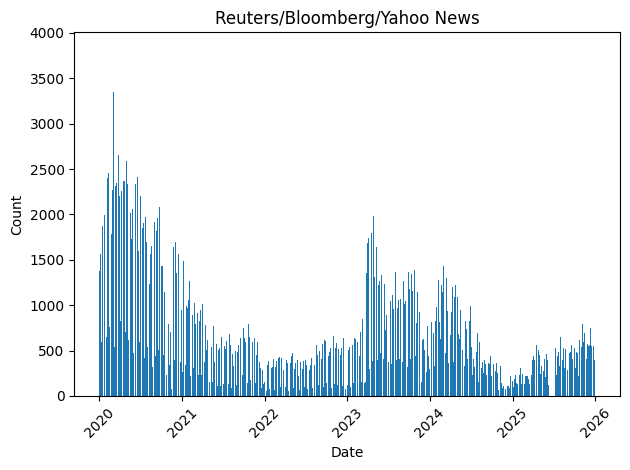

In [4]:
plt.bar(result["date"], result["len"])
plt.title("Reuters/Bloomberg/Yahoo News")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
FILTERED_BRAZIL_PATH = Path("brazil_news")
FILTERED_BRAZIL_PATH.mkdir(exist_ok=True)

if not (FILTERED_BRAZIL_PATH / "brazil.parquet").exists():
    brazil_news = (
        fin_df
        .filter(
            pl.any_horizontal(
                pl.col("locations", "url", "themes", "v2themes", "title").str.contains_any(["brazil"], ascii_case_insensitive=True)
            )
        )
        .drop("date")
        .drop_nulls("title")
    )

    brazil_news.sink_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

In [6]:
brazil_news = pl.scan_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

In [7]:
brazil_counts = (
    brazil_news
    .with_columns(
        pl.col("datetime").dt.date().alias("date")
    )
    .group_by("date")
    .len()
    .collect(engine="streaming")
)

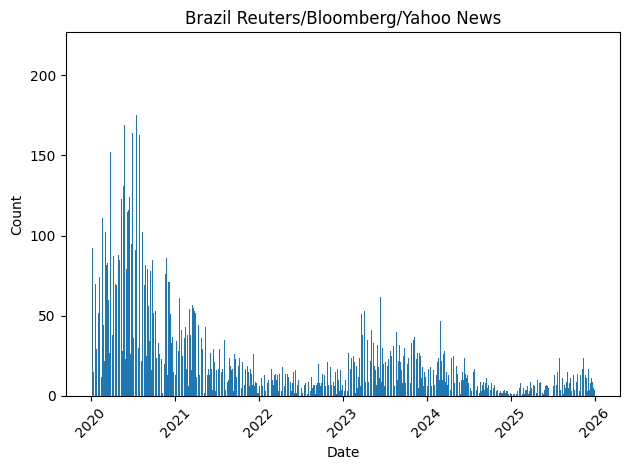

In [8]:
plt.bar(brazil_counts["date"], brazil_counts["len"])
plt.title("Brazil Reuters/Bloomberg/Yahoo News")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [9]:
MODEL = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [10]:
labels = ("negative", "neutral", "positive")

In [11]:
def predict_sentiment(texts: list[str], batch_size=32):

    results: list[dict[str, float]] = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = F.softmax(outputs.logits, dim=1).cpu()

        for p in probs:
            results.append({
                "negative": p[0],
                "neutral": p[1],
                "positive": p[2],
                "sentiment_score": p[2] - p[0]
            })

    return results

In [12]:
titles = brazil_news.select("title").collect(engine="streaming")["title"].to_list()

sentiments = []

for i in tqdm(range(0, len(titles), 512)):
    batch = titles[i:i+512]
    sentiments.extend(predict_sentiment(batch))

100%|██████████| 95/95 [03:17<00:00,  2.08s/it]


In [13]:
sentiment_df = pl.DataFrame(sentiments)

brazil_news = brazil_news.with_columns(sentiment_df)

In [14]:
brazil_daily = (
    brazil_news
    .with_columns(
        pl.col("datetime").dt.date().alias("date")
    )
    .group_by("date")
    .agg([
        pl.mean("sentiment_score").alias("sentiment"),
        pl.std("sentiment_score").alias("sentiment_std"),

        pl.mean("positive").alias("positive_mean"),
        pl.mean("negative").alias("negative_mean"),
        pl.mean("neutral").alias("neutral_mean"),

        pl.mean("tone").alias("tone"),
        pl.std("tone").alias("tone_std"),

        (pl.col("positive") > 0.6).mean().alias("positive_ratio"),
        (pl.col("negative") > 0.6).mean().alias("negative_ratio"),

        pl.len().alias("news_volume")
    ])
    .sort("date")
    .collect(engine="streaming")
)

In [15]:
ibov = pl.from_pandas(yf.download("^BVSP", start="2020-01-01", end="2026-01-01", progress=False, multi_level_index=False).reset_index())
ibov = ibov.rename({col:col.lower() for col in ibov.columns})

ibov = ibov.with_columns([
    pl.col("date").cast(pl.Date),
])

In [16]:
dataset = (
    ibov
    .join(brazil_daily, on="date", how="left")
    .fill_null(0)
    .sort("date")
)

dataset = dataset.with_columns(
    (pl.col("close") / pl.col("close").shift(1) - 1).alias("return"),
)

dataset = dataset.with_columns([

    pl.col("return").abs().alias("abs_return"),

    pl.col("return").abs().shift(-1).alias("target_abs_return_1d"),

    pl.col("return").rolling_std(7).shift(-1).alias("target_volatility_7d"),

    (pl.col("close").shift(-1) / pl.col("close") - 1).alias("target_return_1d"),
    (pl.col("close").shift(-2) / pl.col("close") - 1).alias("target_return_2d"),
    (pl.col("close").shift(-3) / pl.col("close") - 1).alias("target_return_3d"),
    (pl.col("close").shift(-4) / pl.col("close") - 1).alias("target_return_4d"),
    (pl.col("close").shift(-5) / pl.col("close") - 1).alias("target_return_5d"),

    (pl.col("close").shift(-1) > pl.col("close")).cast(pl.Int8).alias("target_direction_1d"),
    (pl.col("close").shift(-2) > pl.col("close")).cast(pl.Int8).alias("target_direction_2d"),
    (pl.col("close").shift(-3) > pl.col("close")).cast(pl.Int8).alias("target_direction_3d"),
    (pl.col("close").shift(-4) > pl.col("close")).cast(pl.Int8).alias("target_direction_4d"),
    (pl.col("close").shift(-5) > pl.col("close")).cast(pl.Int8).alias("target_direction_5d"),

    pl.col("sentiment").shift(1).alias("sentiment_lag_1d"),
    pl.col("sentiment").shift(2).alias("sentiment_lag_2d"),
    pl.col("sentiment").shift(3).alias("sentiment_lag_3d"),
    pl.col("sentiment").shift(4).alias("sentiment_lag_4d"),
    pl.col("sentiment").shift(5).alias("sentiment_lag_5d"),

    (pl.col("sentiment") - pl.col("sentiment").shift(1)).alias("sentiment_momentum_1d"),
    (pl.col("sentiment") - pl.col("sentiment").shift(2)).alias("sentiment_momentum_2d"),
    (pl.col("sentiment") - pl.col("sentiment").shift(3)).alias("sentiment_momentum_3d"),
    
    pl.col("sentiment").shift(1).rolling_mean(3).alias("sentiment_3d_mean"),
    pl.col("sentiment").shift(1).rolling_mean(7).alias("sentiment_7d_mean"),

    (pl.col("sentiment") * pl.col("news_volume")).alias("sentiment_pressure"),
    (pl.col("sentiment") - pl.col("sentiment").rolling_mean(7)).alias("sentiment_surprise"),
    
    pl.col("news_volume").shift(1).alias("volume_lag_1d"),
    pl.col("news_volume").shift(2).alias("volume_lag_2d"),
    pl.col("news_volume").shift(3).alias("volume_lag_3d"),
    pl.col("news_volume").shift(4).alias("volume_lag_4d"),
    pl.col("news_volume").shift(5).alias("volume_lag_5d"),

    (pl.col("news_volume") / (pl.col("news_volume").shift(1).rolling_mean(7) + 1)).alias("news_spike"),

    pl.col("news_volume").shift(1).rolling_mean(3).alias("volume_3d_mean"),
    pl.col("news_volume").shift(1).rolling_mean(7).alias("volume_7d_mean"),

    pl.col("return").shift(1).alias("return_lag_1d"),
    pl.col("return").shift(2).alias("return_lag_2d"),
    pl.col("return").shift(3).alias("return_lag_3d"),
    pl.col("return").shift(4).alias("return_lag_4d"),
    pl.col("return").shift(5).alias("return_lag_5d"),

    (pl.col("tone") - pl.col("tone").shift(3)).alias("tone_momentum"),


])

dataset = dataset.with_columns(
    pl.col("sentiment").forward_fill()
)

dataset = dataset.drop_nulls()
dataset

date,close,high,low,open,volume,sentiment,sentiment_std,positive_mean,negative_mean,neutral_mean,tone,tone_std,positive_ratio,negative_ratio,news_volume,return,abs_return,target_abs_return_1d,target_volatility_7d,target_return_1d,target_return_2d,target_return_3d,target_return_4d,target_return_5d,target_direction_1d,target_direction_2d,target_direction_3d,target_direction_4d,target_direction_5d,sentiment_lag_1d,sentiment_lag_2d,sentiment_lag_3d,sentiment_lag_4d,sentiment_lag_5d,sentiment_momentum_1d,sentiment_momentum_2d,sentiment_momentum_3d,sentiment_3d_mean,sentiment_7d_mean,sentiment_pressure,sentiment_surprise,volume_lag_1d,volume_lag_2d,volume_lag_3d,volume_lag_4d,volume_lag_5d,news_spike,volume_3d_mean,volume_7d_mean,return_lag_1d,return_lag_2d,return_lag_3d,return_lag_4d,return_lag_5d,tone_momentum
date,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f32,f32,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8,i8,i8,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f32
2020-01-13,117325.0,117333.0,115503.0,115503.0,5685100,-0.041599,0.685673,0.399607,0.441206,0.159187,-0.746658,2.928771,0.347826,0.434783,46,0.015774,0.015774,0.002617,0.007557,0.002617,-0.007765,-0.005293,0.009827,0.0131,1,0,0,1,1,-0.019922,0.171487,0.258397,-0.022015,0.230305,-0.021677,-0.213085,-0.299995,0.136654,0.13516,-1.913531,-0.163571,88,75,92,52,46,0.632613,85.0,71.714286,-0.003829,-0.002581,-0.003557,-0.001848,-0.007043,1.380635
2020-01-14,117632.0,117705.0,116610.0,117325.0,5361700,-0.266564,0.675389,0.294048,0.560612,0.14534,-0.278835,1.925272,0.252336,0.53271,107,0.002617,0.002617,0.010354,0.008147,-0.010354,-0.007889,0.007192,0.010456,-0.005152,0,0,1,1,0,-0.041599,-0.019922,0.171487,0.258397,-0.022015,-0.224966,-0.246643,-0.438051,0.036656,0.121973,-28.522394,-0.310863,46,88,75,92,52,1.58351,69.666667,66.571429,0.015774,-0.003829,-0.002581,-0.003557,-0.001848,2.084504
2020-01-15,116414.0,117632.0,116188.0,117632.0,5569400,0.090265,0.590719,0.427972,0.337707,0.234321,-0.059763,2.23361,0.409091,0.348485,66,-0.010354,0.010354,0.002491,0.008196,0.002491,0.01773,0.021028,0.005257,0.016982,1,1,1,1,1,-0.266564,-0.041599,-0.019922,0.171487,0.258397,0.35683,0.131864,0.110187,-0.109362,0.044298,5.957499,0.065972,107,46,88,75,92,0.900585,80.333333,72.285714,0.002617,0.015774,-0.003829,-0.002581,-0.003557,1.473971
2020-01-16,116704.0,117106.0,115961.0,116415.0,5422700,0.187896,0.566666,0.433822,0.245926,0.320252,-0.728562,1.719558,0.392308,0.176923,130,0.002491,0.002491,0.015201,0.009731,0.015201,0.018491,0.002759,0.014455,0.024198,1,1,1,1,1,0.090265,-0.266564,-0.041599,-0.019922,0.171487,0.097631,0.45446,0.229494,-0.072633,0.024293,24.426446,0.133616,66,107,46,88,75,1.707317,73.0,75.142857,-0.010354,0.002617,0.015774,-0.003829,-0.002581,0.018095
2020-01-17,118478.0,118479.0,116710.0,116710.0,4947200,-0.005636,0.624432,0.357751,0.363387,0.278862,0.155591,2.176005,0.34,0.34,50,0.015201,0.015201,0.003241,0.009443,0.003241,-0.012255,-0.000734,0.008862,-0.000861,1,0,0,1,0,0.187896,0.090265,-0.266564,-0.041599,-0.019922,-0.193532,-0.095901,0.260928,0.003865,0.05428,-0.281813,-0.022197,130,66,107,46,88,0.572831,101.0,86.285714,0.002491,-0.010354,0.002617,0.015774,-0.003829,0.434425
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-12-15,162482.0,163073.0,160766.0,160766.0,8229000,0.375208,0.623997,0.609319,0.234111,0.15657,0.849102,1.861119,0.642857,0.214286,14,0.010674,0.010674,0.024027,0.011953,-0.024027,-0.031727,-0.028058,-0.024674,-0.026711,0,0,0,0,0,0.108297,0.177726,0.175773,0.021288,0.197916,0.266911,0.197482,0.199435,0.153932,0.134395,5.252908,0.212557,10,11,13,12,4,1.209877,11.333333,10.571429,0.009906,0.000717,0.006925,-0.001302,0.005198,0.658513
2025-12-16,158578.0,162482.0,158558.0,162482.0,9920300,0.429655,0.643524,0.70282,0.273165,0.024015,0.3711,1.369398,0.8,0.2,10,-0.024027,0.024027,0.007889,0.012235,-0.007889,-0.00413,-0.000662,

In [17]:
TARGET = "target_direction_1d"

FEATURE_POOL = [
    c for c in dataset.columns
    if not c.startswith("target")
    and c not in {"date", "open", "high", "low", "close"}
]

# convert to numpy once
X_all = dataset.select(FEATURE_POOL)
y_all = dataset[TARGET]

split = int(len(dataset) * 0.8)

X_train = X_all[:split]
X_test = X_all[split:]

y_train = y_all[:split]
y_test = y_all[split:]

In [18]:
base_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

base_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

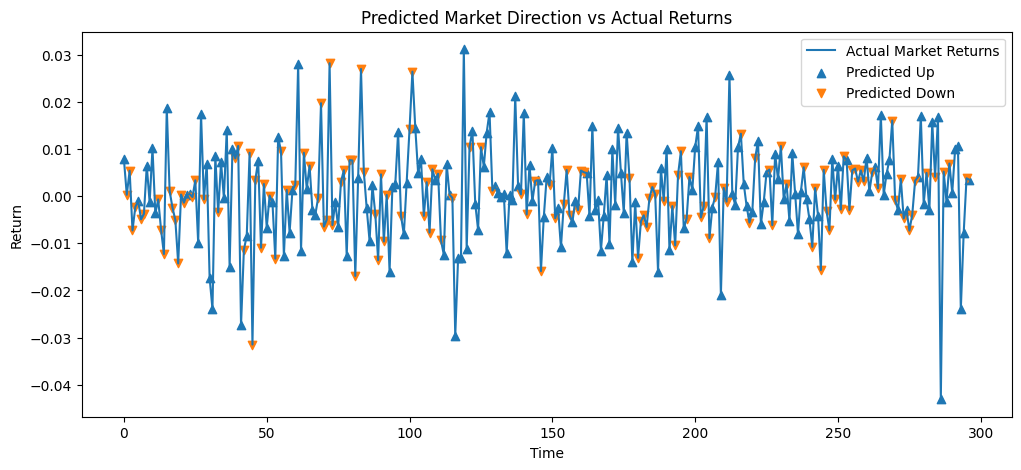

In [19]:
# predict probabilities and direction
dir_prob = base_model.predict_proba(X_test)[:,1]
dir_pred = (dir_prob > 0.5).astype(int)

# actual direction
y_test_np = y_test.to_numpy()

# market returns for the same test period
returns_test = dataset["return"].to_numpy()[split:]

plt.figure(figsize=(12,5))

plt.plot(returns_test, label="Actual Market Returns")

# predicted up points
up_idx = dir_pred == 1
plt.scatter(
    [i for i in range(len(returns_test)) if dir_pred[i]==1],
    returns_test[dir_pred==1],
    marker="^",
    label="Predicted Up"
)

plt.scatter(
    [i for i in range(len(returns_test)) if dir_pred[i]==0],
    returns_test[dir_pred==0],
    marker="v",
    label="Predicted Down"
)

plt.title("Predicted Market Direction vs Actual Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()

plt.show()

In [20]:
print("Direction accuracy:", accuracy_score(y_test_np, dir_pred))

Direction accuracy: 0.5084175084175084


In [ ]:
importances = base_model.feature_importances_

feature_ranking = sorted(
    zip(FEATURE_POOL, importances),
    key=lambda x: x[1],
    reverse=True
)

TOP_K = 12

top_features = [f for f, _ in feature_ranking[:TOP_K]]

print("Top features:")
for f, imp in feature_ranking[:TOP_K]:
    print(f"{f:<25} {imp:.4f}")

Top features:
sentiment_surprise        0.0323
news_spike                0.0303
sentiment_momentum_3d     0.0299
return                    0.0288
sentiment_lag_1d          0.0275
tone_momentum             0.0273
sentiment_lag_3d          0.0271
negative_ratio            0.0270
abs_return                0.0269
return_lag_5d             0.0269
return_lag_4d             0.0266
sentiment_pressure        0.0266


In [22]:
N_EXPERIMENTS = 1000

random_feature_sets = []

for _ in range(N_EXPERIMENTS):

    size = random.randint(2, min(6, len(top_features)))

    combo = tuple(sorted(random.sample(top_features, size)))

    random_feature_sets.append(combo)

# remove duplicates
random_feature_sets = list(set(random_feature_sets))

print("Feature sets:", len(random_feature_sets))

Feature sets: 736


In [23]:
MODELS = {
    "xgb": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        eval_metric="logloss"
    ),

    "rf": RandomForestClassifier(
        n_estimators=300,
        max_depth=8
    ),

    "logreg": LogisticRegression(max_iter=2000)
}

In [24]:
FEATURE_INDEX = {f: i for i, f in enumerate(FEATURE_POOL)}

def evaluate_model(model, features):

    idx = [FEATURE_INDEX[f] for f in features]

    X_tr = X_train[:, idx]
    X_te = X_test[:, idx]

    model.fit(X_tr, y_train)

    prob = model.predict_proba(X_te)[:,1]
    pred = (prob > 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, prob)
    }

In [25]:
results = []

for features in tqdm(random_feature_sets):

    for model_name, model_template in MODELS.items():

        try:

            model = model_template.__class__(**model_template.get_params())

            metrics = evaluate_model(model, features)

            results.append({
                "model": model_name,
                "features": features,
                "n_features": len(features),
                "accuracy": metrics["accuracy"],
                "f1": metrics["f1"],
                "roc_auc": metrics["roc_auc"]
            })

        except Exception:
            pass

100%|██████████| 736/736 [05:12<00:00,  2.36it/s]


In [26]:
results_df = (
    pl.DataFrame(results)
    .sort("roc_auc", descending=True)
)

print(results_df.head(20))

shape: (20, 6)
┌───────┬─────────────────────────────────┬────────────┬──────────┬──────────┬──────────┐
│ model ┆ features                        ┆ n_features ┆ accuracy ┆ f1       ┆ roc_auc  │
│ ---   ┆ ---                             ┆ ---        ┆ ---      ┆ ---      ┆ ---      │
│ str   ┆ list[str]                       ┆ i64        ┆ f64      ┆ f64      ┆ f64      │
╞═══════╪═════════════════════════════════╪════════════╪══════════╪══════════╪══════════╡
│ rf    ┆ ["abs_return", "negative_ratio… ┆ 2          ┆ 0.56229  ┆ 0.580645 ┆ 0.575449 │
│ xgb   ┆ ["negative_ratio", "return_lag… ┆ 4          ┆ 0.56229  ┆ 0.580645 ┆ 0.56962  │
│ rf    ┆ ["abs_return", "negative_ratio… ┆ 4          ┆ 0.552189 ┆ 0.542955 ┆ 0.565841 │
│ xgb   ┆ ["abs_return", "negative_ratio… ┆ 3          ┆ 0.555556 ┆ 0.565789 ┆ 0.565841 │
│ xgb   ┆ ["abs_return", "negative_ratio… ┆ 2          ┆ 0.555556 ┆ 0.547945 ┆ 0.564885 │
│ …     ┆ …                               ┆ …          ┆ …        ┆ …        ┆ …     

In [27]:
# RETURN MAGNITUDE MODEL

TARGET_RETURN = "target_return_1d"

y_return_all = dataset[TARGET_RETURN]

y_train_return = y_return_all[:split]
y_test_return = y_return_all[split:]

reg_model = XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8
)

reg_model.fit(X_train, y_train_return)

pred_returns = reg_model.predict(X_test)

rmse = root_mean_squared_error(y_test_return, pred_returns)
mae = mean_absolute_error(y_test_return, pred_returns)

print("Return prediction RMSE:", rmse)
print("Return prediction MAE:", mae)

Return prediction RMSE: 0.010477324986385808
Return prediction MAE: 0.007884222822372094


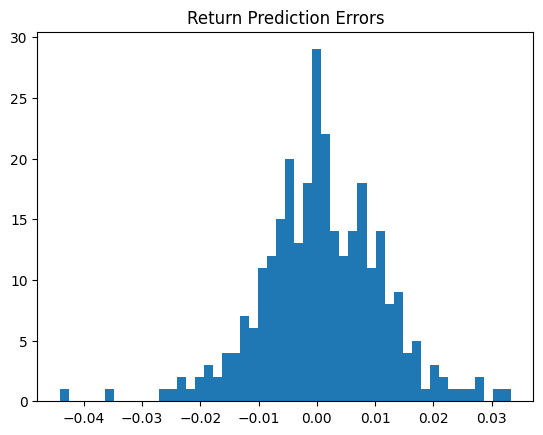

In [28]:
errors = y_test_return - pred_returns

plt.hist(errors, bins=50)
plt.title("Return Prediction Errors")
plt.show()

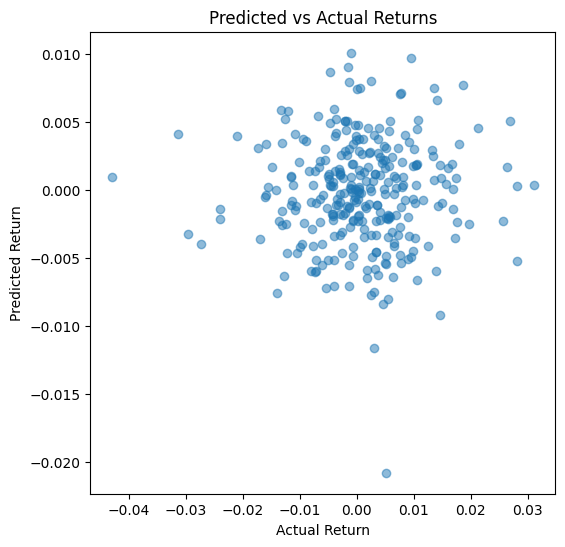

In [29]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_return, pred_returns, alpha=0.5)

plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.title("Predicted vs Actual Returns")

plt.show()

In [30]:
TARGET_VOL = "target_volatility_7d"

y_vol_all = dataset[TARGET_VOL]

y_train_vol = y_vol_all[:split]
y_test_vol = y_vol_all[split:]

vol_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05
)

vol_model.fit(X_train, y_train_vol)

pred_vol = vol_model.predict(X_test)

vol_rmse = root_mean_squared_error(y_test_vol, pred_vol)

print("Volatility RMSE:", vol_rmse)

Volatility RMSE: 0.0019300175544760877


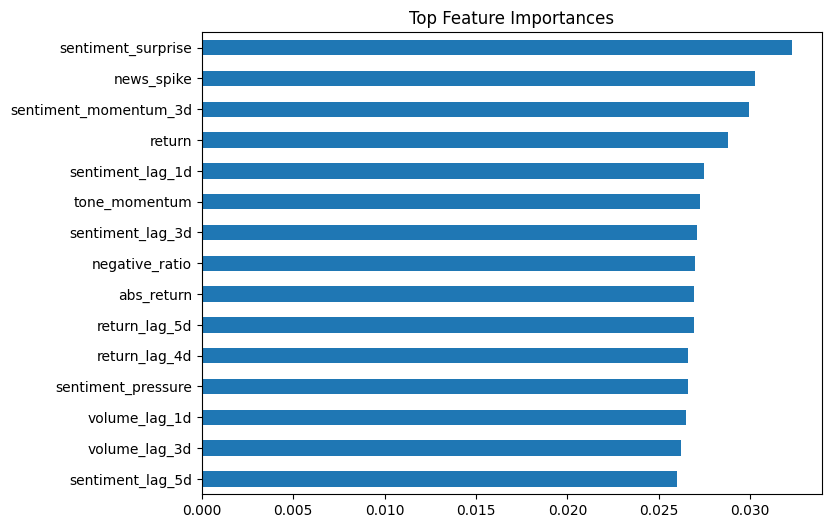

In [31]:
feat_imp = pd.Series(
    importances,
    index=FEATURE_POOL
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(15).plot(kind="barh")
plt.title("Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()

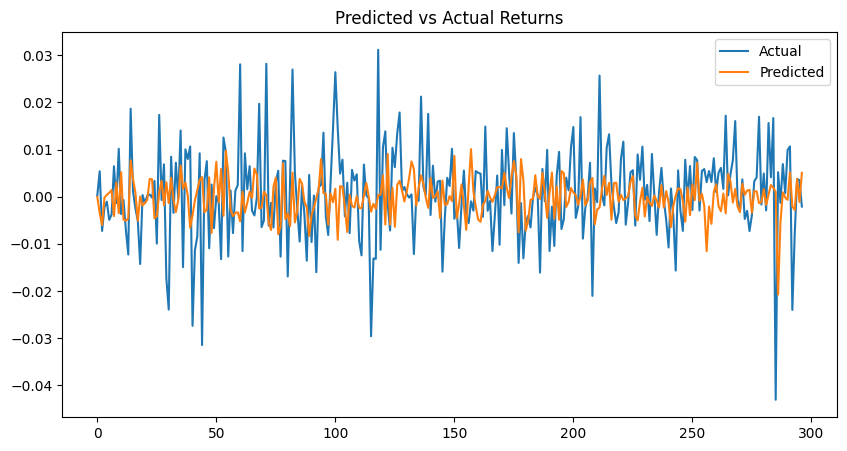

In [32]:
plt.figure(figsize=(10,5))

plt.plot(y_test_return.to_numpy(), label="Actual")
plt.plot(pred_returns, label="Predicted")

plt.title("Predicted vs Actual Returns")
plt.legend()
plt.show()

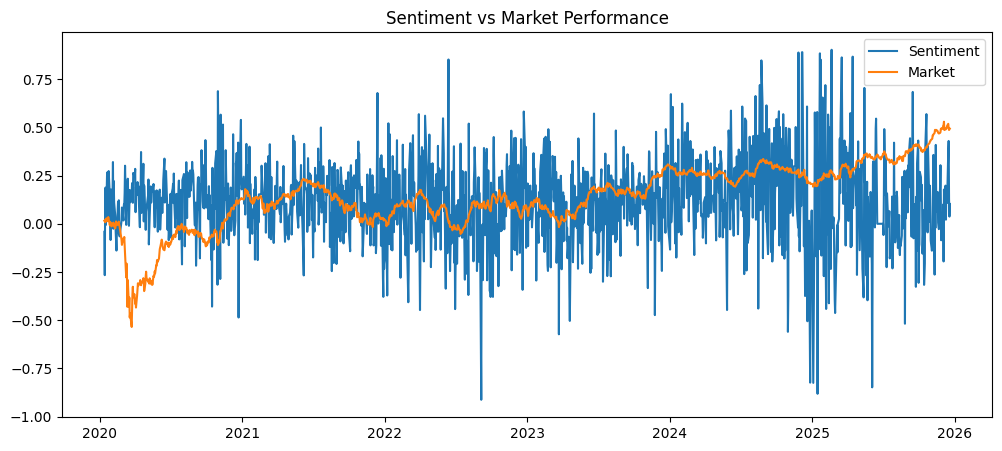

In [33]:
plt.figure(figsize=(12,5))

plt.plot(dataset["date"], dataset["sentiment"], label="Sentiment")
plt.plot(dataset["date"], dataset["return"].cum_sum(), label="Market")

plt.legend()
plt.title("Sentiment vs Market Performance")
plt.show()

In [34]:
tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_idx, test_idx in tscv.split(X_all):

    X_tr = X_all[train_idx]
    X_te = X_all[test_idx]

    y_tr = y_all[train_idx]
    y_te = y_all[test_idx]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.03,
        eval_metric="logloss"
    )

    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)

    scores.append(accuracy_score(y_te, pred))

print("Walk-forward accuracy:", sum(scores)/len(scores))

Walk-forward accuracy: 0.491497975708502
